In [ ]:
!nvidia-smi

Fri Aug 23 23:08:50 2024       
+---------------------------------------------------------------------------------------+
| NVIDIA-SMI 535.104.05             Driver Version: 535.104.05   CUDA Version: 12.2     |
|-----------------------------------------+----------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |         Memory-Usage | GPU-Util  Compute M. |
|                                         |                      |               MIG M. |
|=========================================+======================+======================|
|   0  Tesla T4                       Off | 00000000:00:04.0 Off |                    0 |
| N/A   43C    P8              10W /  70W |      0MiB / 15360MiB |      0%      Default |
|                                         |                      |                  N/A |
+-----------------------------------------+----------------------+--

In [ ]:
!cat /proc/cpuinfo

processor	: 0
vendor_id	: GenuineIntel
cpu family	: 6
model		: 85
model name	: Intel(R) Xeon(R) CPU @ 2.00GHz
stepping	: 3
microcode	: 0xffffffff
cpu MHz		: 2000.156
cache size	: 39424 KB
physical id	: 0
siblings	: 8
core id		: 0
cpu cores	: 4
apicid		: 0
initial apicid	: 0
fpu		: yes
fpu_exception	: yes
cpuid level	: 13
wp		: yes
flags		: fpu vme de pse tsc msr pae mce cx8 apic sep mtrr pge mca cmov pat pse36 clflush mmx fxsr sse sse2 ss ht syscall nx pdpe1gb rdtscp lm constant_tsc rep_good nopl xtopology nonstop_tsc cpuid tsc_known_freq pni pclmulqdq ssse3 fma cx16 pcid sse4_1 sse4_2 x2apic movbe popcnt aes xsave avx f16c rdrand hypervisor lahf_lm abm 3dnowprefetch invpcid_single ssbd ibrs ibpb stibp fsgsbase tsc_adjust bmi1 hle avx2 smep bmi2 erms invpcid rtm mpx avx512f avx512dq rdseed adx smap clflushopt clwb avx512cd avx512bw avx512vl xsaveopt xsavec xgetbv1 xsaves arat md_clear arch_capabilities
bugs		: cpu_meltdown spectre_v1 spectre_v2 spec_store_bypass l1tf mds swapgs taa mmi

In [ ]:
!pip install transformers datasets torch nltk bert_score transformers[torch] accelerate pyemd rouge_score moverscore pytorch_pretrained_bert -U

In [ ]:
import torch
from transformers import GPT2LMHeadModel, GPT2Tokenizer

# Load model and tokenizer
model_name = "distilgpt2"
model = GPT2LMHeadModel.from_pretrained(model_name)

# Move model to GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/762 [00:00<?, ?B/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


model.safetensors:   0%|          | 0.00/353M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

GPT2LMHeadModel(
  (transformer): GPT2Model(
    (wte): Embedding(50257, 768)
    (wpe): Embedding(1024, 768)
    (drop): Dropout(p=0.1, inplace=False)
    (h): ModuleList(
      (0-5): 6 x GPT2Block(
        (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (attn): GPT2Attention(
          (c_attn): Conv1D(nf=2304, nx=768)
          (c_proj): Conv1D(nf=768, nx=768)
          (attn_dropout): Dropout(p=0.1, inplace=False)
          (resid_dropout): Dropout(p=0.1, inplace=False)
        )
        (ln_2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (mlp): GPT2MLP(
          (c_fc): Conv1D(nf=3072, nx=768)
          (c_proj): Conv1D(nf=768, nx=3072)
          (act): NewGELUActivation()
          (dropout): Dropout(p=0.1, inplace=False)
        )
      )
    )
    (ln_f): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
  )
  (lm_head): Linear(in_features=768, out_features=50257, bias=False)
)

In [ ]:
[768, 1024, 6, 12, 0.1, 0.1, 0.0]

In [ ]:
# Function to assign each length to a bin
def assign_bin(length, bin_edges):
    return np.digitize(length, bin_edges) - 1

In [ ]:
import numpy as np
import pandas as pd
from datasets import load_dataset, concatenate_datasets

# Load the WikiText dataset
datasets = load_dataset('wikitext', 'wikitext-2-raw-v1')
dataset = concatenate_datasets([datasets['train'], datasets['validation']])
test_dataset = datasets['test']

# Add length column for length-based stratification
dataset = dataset.map(lambda example: {'length': len(example['text'].split())})

# Calculate bin edges using quantiles
num_bins = 3
bin_edges = np.quantile(dataset['length'], np.linspace(0, 1, num_bins + 1))
dataset = dataset.map(lambda example: {'length_bin': assign_bin(example['length'], bin_edges)})

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

test-00000-of-00001.parquet:   0%|          | 0.00/733k [00:00<?, ?B/s]

train-00000-of-00001.parquet:   0%|          | 0.00/6.36M [00:00<?, ?B/s]

validation-00000-of-00001.parquet:   0%|          | 0.00/657k [00:00<?, ?B/s]

Generating test split:   0%|          | 0/4358 [00:00<?, ? examples/s]

Generating train split:   0%|          | 0/36718 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/3760 [00:00<?, ? examples/s]

Map:   0%|          | 0/40478 [00:00<?, ? examples/s]

Map:   0%|          | 0/40478 [00:00<?, ? examples/s]

In [ ]:
dataset

Dataset({
    features: ['text', 'length', 'length_bin'],
    num_rows: 40478
})

In [ ]:
test_dataset

Dataset({
    features: ['text'],
    num_rows: 4358
})

In [ ]:
bin_edges

array([  0.,   0.,  70., 699.])

In [ ]:
for i, example in enumerate(dataset.select(range(10))):
    print(f'Example {i}: length - {example["length"]}, length_bin - {example["length_bin"]}')

Example 0: length - 0, length_bin - 1
Example 1: length - 5, length_bin - 1
Example 2: length - 0, length_bin - 1
Example 3: length - 127, length_bin - 2
Example 4: length - 91, length_bin - 2
Example 5: length - 101, length_bin - 2
Example 6: length - 0, length_bin - 1
Example 7: length - 5, length_bin - 1
Example 8: length - 0, length_bin - 1
Example 9: length - 211, length_bin - 2


In [ ]:
tokenizer.pad_token = tokenizer.eos_token

def tokenize_function(examples):
    # Tokenize the input text
    tokenized_output = tokenizer(examples['text'], truncation=True, padding='max_length', max_length=128)

    # Shift the input ids to create the labels
    tokenized_output['labels'] = tokenized_output['input_ids'].copy()

    return tokenized_output

tokenized_dataset = dataset.map(tokenize_function, batched=True, remove_columns=["text"])
tokenized_test_dataset = test_dataset.map(tokenize_function, batched=True, remove_columns=["text"])

tokenized_dataset.set_format(type='torch', columns=['input_ids', 'attention_mask', 'labels'])
tokenized_test_dataset.set_format(type='torch', columns=['input_ids', 'attention_mask', 'labels'])

Map:   0%|          | 0/40478 [00:00<?, ? examples/s]

Map:   0%|          | 0/4358 [00:00<?, ? examples/s]

In [ ]:
tokenized_dataset[1]

{'input_ids': tensor([  796,   569, 18354,  7496, 17740,  6711,   796,   220,   198, 50256,
         50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256,
         50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256,
         50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256,
         50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256,
         50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256,
         50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256,
         50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256,
         50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256,
         50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256,
         50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256,
         50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256,
         50256, 50256, 50256, 50256, 50

In [ ]:
import time
from transformers import TrainerCallback, TrainerState, TrainerControl, TrainingArguments

# Custom callback to log epoch time
class CustomCallback(TrainerCallback):
    def __init__(self):
        self.epoch_times = []
        self.val_losses = []

    def on_epoch_begin(self, args: TrainingArguments, state: TrainerState, control: TrainerControl, **kwargs):
        self.start_time = time.time()

    def on_epoch_end(self, args: TrainingArguments, state: TrainerState, control: TrainerControl, **kwargs):
        end_time = time.time()
        epoch_time = end_time - self.start_time
        self.epoch_times.append(epoch_time)
        print(f"Epoch {state.epoch} took {epoch_time:.2f} seconds")

    def on_evaluate(self, args: TrainingArguments, state: TrainerState, control: TrainerControl, **kwargs):
        self.val_losses.append(state.log_history[-1]['eval_loss'])
        print(f"Validation loss at epoch {state.epoch}: {state.log_history[-1]['eval_loss']}")

    def reset(self):
        self.epoch_times = []
        self.val_losses = []

custom_callback = CustomCallback()

In [ ]:
def cut_text_for_generation(text, cut_percentage=0.3):
    cut_point = int(len(text) * (1 - cut_percentage))
    return text[:cut_point], text[cut_point:]

In [ ]:
from transformers import GenerationConfig

def generate_text(input_ids, attention_mask, model, tokenizer):
    input_ids = input_ids.to(device)
    attention_mask = attention_mask.to(device)

    gen_config = GenerationConfig.from_pretrained("distilgpt2")  # or any fallback
    gen_config.max_new_tokens = 50
    gen_config.num_return_sequences = 1
    gen_config.pad_token_id = tokenizer.eos_token_id

    outputs = model.generate(
        input_ids=input_ids,
        attention_mask=attention_mask,
        generation_config=gen_config
    )
    return tokenizer.decode(outputs[0], skip_special_tokens=True)


In [ ]:
from sklearn.model_selection import StratifiedKFold

kf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

In [ ]:
import pickle

model_paths = [
    'drive/MyDrive/NAS/Israel/config_1/best_model.pkl',
    'drive/MyDrive/NAS/Israel/config_3/best_model.pkl',
    'drive/MyDrive/NAS/Israel/config1_SMSEMOA/best_model.pkl',
    'drive/MyDrive/NAS/Israel/config_2/best_model_mid.pkl'
]

models = []

for model_path in model_paths:
  with open(model_path, "rb") as f:
    model = pickle.load(f)
  models.append(model)

models

[GPT2LMHeadModel(
   (transformer): GPT2Model(
     (wte): Embedding(50257, 8)
     (wpe): Embedding(512, 8)
     (drop): Dropout(p=0.1, inplace=False)
     (h): ModuleList(
       (0-47): 48 x GPT2Block(
         (ln_1): LayerNorm((8,), eps=1e-05, elementwise_affine=True)
         (attn): GPT2Attention(
           (c_attn): Conv1D(nf=24, nx=8)
           (c_proj): Conv1D(nf=8, nx=8)
           (attn_dropout): Dropout(p=0.0, inplace=False)
           (resid_dropout): Dropout(p=0.0, inplace=False)
         )
         (ln_2): LayerNorm((8,), eps=1e-05, elementwise_affine=True)
         (mlp): GPT2MLP(
           (c_fc): Conv1D(nf=32, nx=8)
           (c_proj): Conv1D(nf=8, nx=32)
           (act): GELUActivation()
           (dropout): Dropout(p=0.0, inplace=False)
         )
       )
     )
     (ln_f): LayerNorm((8,), eps=1e-05, elementwise_affine=True)
   )
   (lm_head): Linear(in_features=8, out_features=50257, bias=False)
 ),
 GPT2LMHeadModel(
   (transformer): GPT2Model(
     (wte)

In [ ]:
print(f"Device is {device}")

Device is cuda


In [ ]:
from transformers import AutoModel, AutoTokenizer

model_id = "bert-base-uncased"
AutoTokenizer.from_pretrained(model_id)
AutoModel.from_pretrained(model_id)

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

BertModel(
  (embeddings): BertEmbeddings(
    (word_embeddings): Embedding(30522, 768, padding_idx=0)
    (position_embeddings): Embedding(512, 768)
    (token_type_embeddings): Embedding(2, 768)
    (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (encoder): BertEncoder(
    (layer): ModuleList(
      (0-11): 12 x BertLayer(
        (attention): BertAttention(
          (self): BertSdpaSelfAttention(
            (query): Linear(in_features=768, out_features=768, bias=True)
            (key): Linear(in_features=768, out_features=768, bias=True)
            (value): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (output): BertSelfOutput(
            (dense): Linear(in_features=768, out_features=768, bias=True)
            (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
            (dropout): Dropout(p=0.1, inplace=False

In [ ]:
import os
import ast
import numpy as np

# Root directory where model folders live
root_dir = "drive/MyDrive/NAS/Israel/NAS-for-Text-Generation/models/distilgpt2/NAS_models"

# Initialize dictionaries to hold metrics for each model
metrics_per_model = {}

# Metrics we expect
metric_names = [
    "epoch_time", "val_loss", "P", "R", "F1",
    "BLEU", "METEOR", "GLEU", "ROUGE1", "ROUGE2", "ROUGEL"
]

# Traverse each model folder (model_0, model_1, ...)
for model_dir in os.listdir(root_dir):
    model_path = os.path.join(root_dir, model_dir)
    if os.path.isdir(model_path) and model_dir.startswith("model_"):
        fold_metrics = {key: [] for key in metric_names}

        for fold in range(3):
            metrics_file = os.path.join(model_path, f"results_fold_{fold}", f"metrics_fold_{fold}.txt")
            if os.path.isfile(metrics_file):
                with open(metrics_file, 'r') as f:
                    lines = f.readlines()
                    fold_metrics["epoch_time"].append(ast.literal_eval(lines[0].strip()))
                    fold_metrics["val_loss"].append(ast.literal_eval(lines[1].strip()))
                    fold_metrics["P"].append(float(lines[2].strip()))
                    fold_metrics["R"].append(float(lines[3].strip()))
                    fold_metrics["F1"].append(float(lines[4].strip()))
                    fold_metrics["BLEU"].append(float(lines[5].strip()))
                    fold_metrics["METEOR"].append(float(lines[6].strip()))
                    fold_metrics["GLEU"].append(float(lines[7].strip()))
                    fold_metrics["ROUGE1"].append(float(lines[8].strip()))
                    fold_metrics["ROUGE2"].append(float(lines[9].strip()))
                    fold_metrics["ROUGEL"].append(float(lines[10].strip()))

        # Compute mean of each metric across folds
        mean_metrics = {
            key: np.mean(fold_metrics[key], axis=0) if key in ["epoch_time", "val_loss"] else np.mean(fold_metrics[key])
            for key in fold_metrics
        }
        metrics_per_model[model_dir] = mean_metrics

import pandas as pd
df = pd.DataFrame.from_dict(metrics_per_model, orient='index')
import ace_tools as tools; tools.display_dataframe_to_user(name="Mean Evaluation Metrics by Model", dataframe=df)


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=3.
  warnings.warn(


Fold 1, # epochs: 1.5


wandb: WARNING The `run_name` is currently set to the same value as `TrainingArguments.output_dir`. If this was not intended, please specify a different run name by setting the `TrainingArguments.run_name` parameter.
wandb: Using wandb-core as the SDK backend.  Please refer to https://wandb.me/wandb-core for more information.


<IPython.core.display.Javascript object>

wandb: Logging into wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: You can find your API key in your browser here: https://wandb.ai/authorize
wandb: Paste an API key from your profile and hit enter:wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: a01378705 (a01378705-tecnol-gico-de-monterrey) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


...

calculating scores...
computing bert embedding.


  0%|          | 0/44 [00:00<?, ?it/s]

computing greedy matching.


  0%|          | 0/24 [00:00<?, ?it/s]

done in 13.26 seconds, 111.44 sentences/sec
BERTScore - Precision: 0.6085641384124756, Recall: 0.7932717204093933, F1: 0.6855164766311646
Average BLEU score: 0.20570307200927448
Average METEOR score: 0.6985433527976506
Average GLEU score: 0.22840607570569352
Average ROUGE-1 score: 0.29752167414889785
Average ROUGE-2 score: 0.26106260029545986
Average ROUGE-L score: 0.29752167414889785


In [ ]:
import os
import ast

root_dir = "drive/MyDrive/NAS/Israel/NAS-for-Text-Generation/models/distilgpt2"

# Initialize arrays to store metrics
epoch_time = []
P_arr = []
R_arr = []
F1_arr = []
BLEU_arr = []
METEOR_arr = []
GLEU_arr = []
ROUGE1_arr = []
ROUGE2_arr = []
ROUGEL_arr = []
mover_arr = []
loss_arr = []

# Function to read metrics from a file and store them in the corresponding arrays
def read_metrics_from_file(file_path):
    with open(file_path, 'r') as f:
        lines = f.readlines()
        epoch_time.append(ast.literal_eval(lines[0].strip()))
        loss_arr.append(ast.literal_eval(lines[1].strip()))
        P_arr.append(float(lines[2].strip()))
        R_arr.append(float(lines[3].strip()))
        F1_arr.append(float(lines[4].strip()))
        BLEU_arr.append(float(lines[5].strip()))
        METEOR_arr.append(float(lines[6].strip()))
        GLEU_arr.append(float(lines[7].strip()))
        ROUGE1_arr.append(float(lines[8].strip()))
        ROUGE2_arr.append(float(lines[9].strip()))
        ROUGEL_arr.append(float(lines[10].strip()))
        mover_arr.append(float(lines[11].strip()))

# Traverse the directory structure and read the metrics from each file
for fold_dir in os.listdir(root_dir):
    fold_path = os.path.join(root_dir, fold_dir)
    if os.path.isdir(fold_path):
        metrics_file = os.path.join(fold_path, f"metrics_fold_{fold_dir.split('_')[-1]}.txt")
        if os.path.isfile(metrics_file):
            read_metrics_from_file(metrics_file)

# Print the arrays to verify the results
print("Epoch Times:", epoch_time)
print("Epoch Validation Losses:", loss_arr)
print("Precision:", P_arr)
print("Recall:", R_arr)
print("F1 Scores:", F1_arr)
print("BLEU Scores:", BLEU_arr)
print("METEOR Scores:", METEOR_arr)
print("GLEU Scores:", GLEU_arr)
print("ROUGE-1 Scores:", ROUGE1_arr)
print("ROUGE-2 Scores:", ROUGE2_arr)
print("ROUGE-L Scores:", ROUGEL_arr)
print("MoverScores:", mover_arr)

Epoch Times: [[455.9341995716095, 452.718341588974, 470.84277725219727], [450.0010094642639, 447.7327883243561, 448.7028203010559, 452.8178837299347, 473.844749212265], [450.2624864578247, 450.4368977546692, 448.8765995502472, 450.2364423274994, 450.1579031944275, 450.01015043258667, 449.9458837509155, 447.9396586418152, 449.1820020675659, 469.68784976005554], [447.66587829589844, 447.413681268692, 447.68331933021545, 451.54543375968933, 448.0469536781311, 452.3620057106018, 451.93583369255066, 450.3230209350586, 450.3636028766632, 450.72800374031067, 451.78412652015686, 473.8059022426605], [452.24515438079834, 448.96627855300903, 449.7928593158722, 451.2789306640625, 451.3417139053345, 451.10356736183167, 452.3804717063904, 449.9713759422302, 452.83058500289917, 449.91351199150085, 455.19227957725525, 454.73719453811646, 450.4031903743744, 449.43031191825867, 487.14995217323303]]
Epoch Validation Losses: [[1.3004215955734253, 1.2792773246765137, 1.2760820388793945], [1.300352573394775

In [ ]:
plot_dir = os.path.join(root_dir, 'plots')
if not os.path.exists(plot_dir):
    os.makedirs(plot_dir)

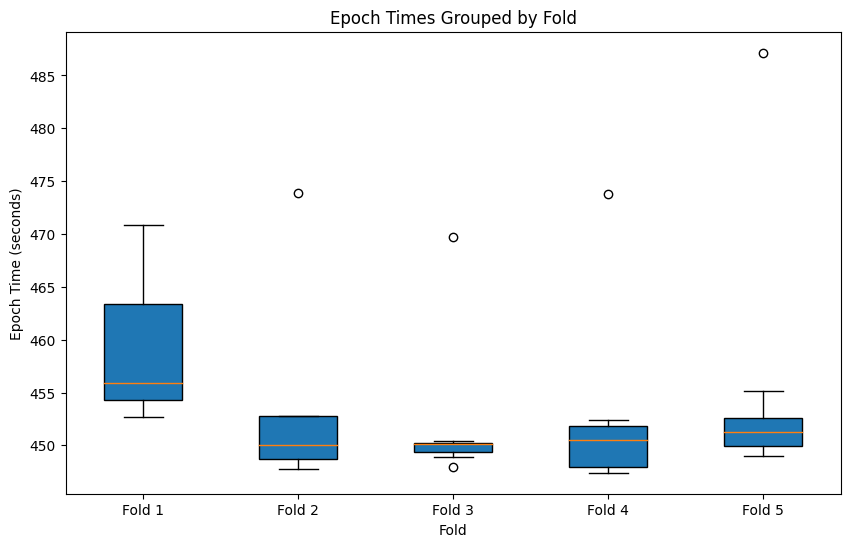

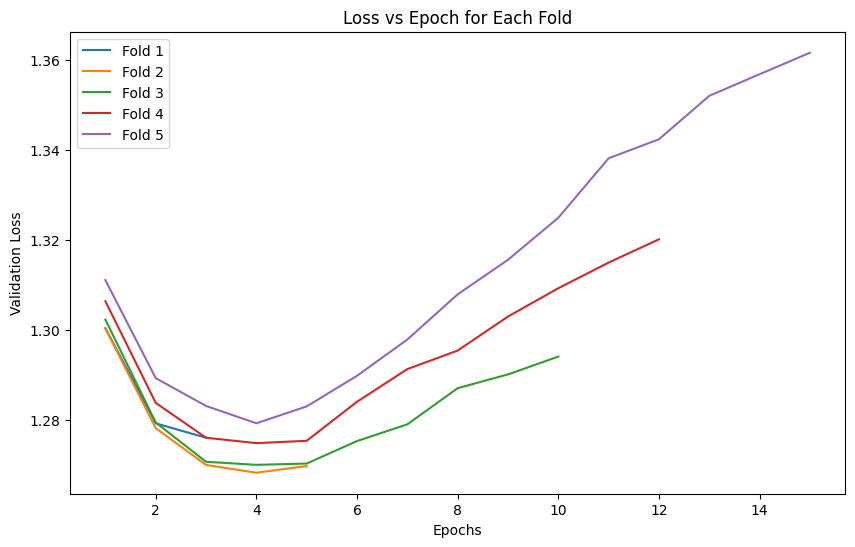

In [ ]:
# Plot loss vs each epoch for each fold
plt.figure(figsize=(10, 6))
for fold in fold_numbers:
    plt.plot(range(1, len(loss_arr[fold - 1]) + 1), loss_arr[fold - 1], label=f'Fold {fold}')
plt.xlabel('Epochs')
plt.ylabel('Validation Loss')
plt.title('Loss vs Epoch for Each Fold')
plt.savefig(os.path.join(plot_dir, 'loss_vs_epoch.png'))
plt.legend()
plt.show()

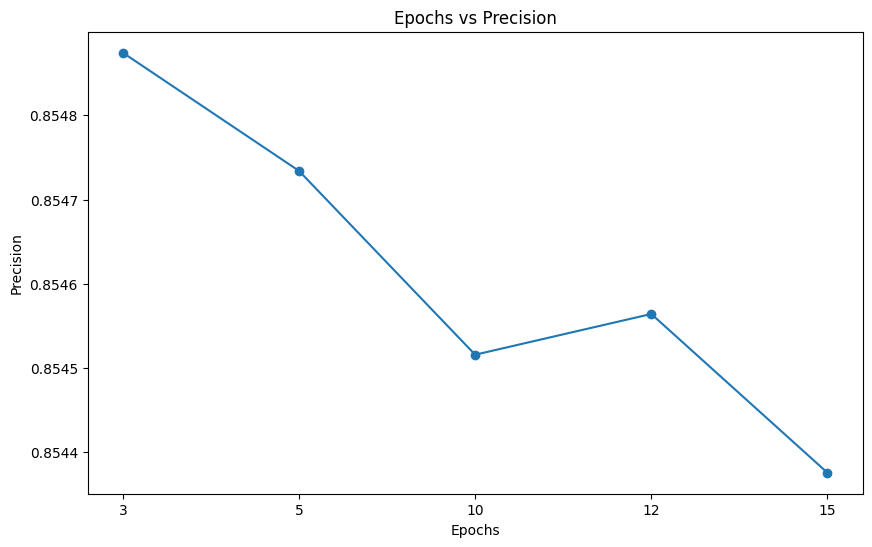

In [ ]:
epochs = ["3", "5", "10", "12", "15"]

# Plot epochs vs P
plt.figure(figsize=(10, 6))
plt.plot(epochs, P_arr, marker='o', label='Precision')
plt.xlabel('Epochs')
plt.ylabel('Precision')
plt.title('Epochs vs Precision')
plt.xticks(epochs)
plt.savefig(os.path.join(plot_dir, 'epochs_vs_precision.png'))
plt.show()

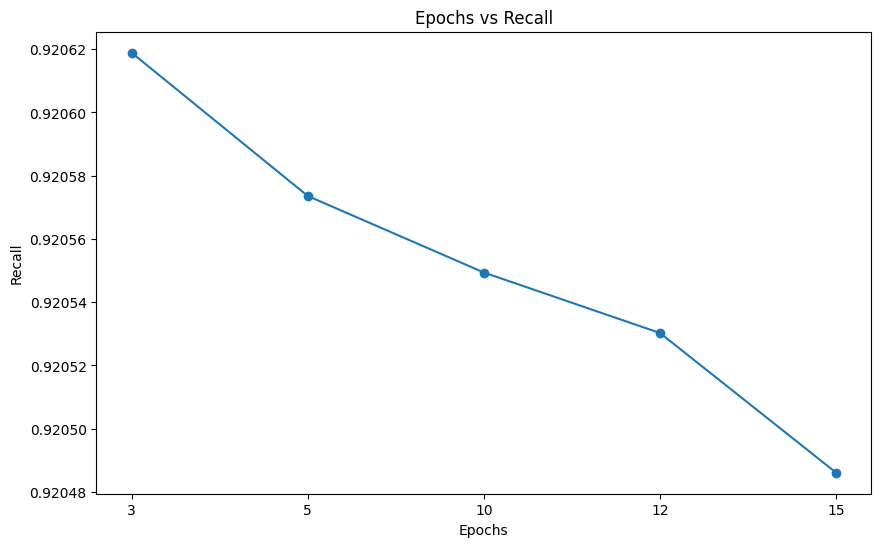

In [ ]:
# Plot epochs vs R
plt.figure(figsize=(10, 6))
plt.plot(epochs[:len(R_arr)], R_arr, marker='o', label='Recall')
plt.xlabel('Epochs')
plt.ylabel('Recall')
plt.title('Epochs vs Recall')
plt.savefig(os.path.join(plot_dir, 'epochs_vs_recall.png'))
plt.xticks(epochs)
plt.show()

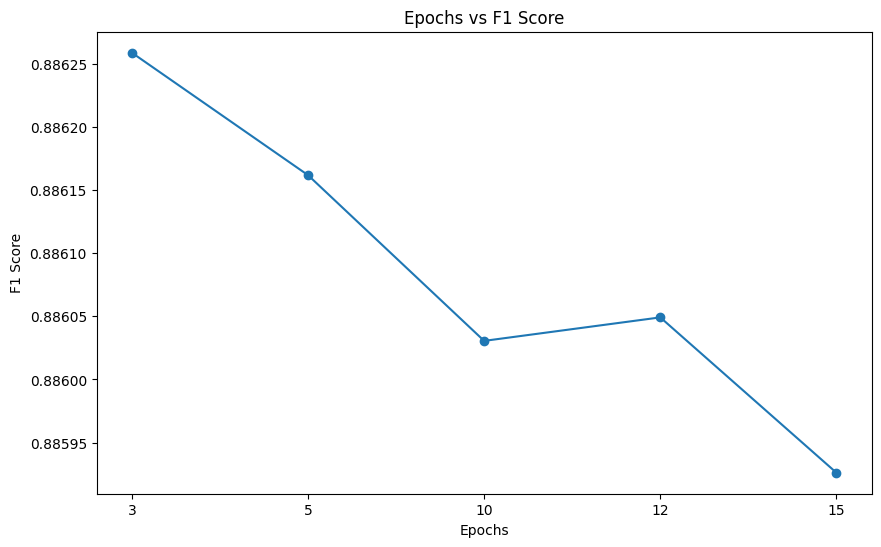

In [ ]:
# Plot epochs vs F1
plt.figure(figsize=(10, 6))
plt.plot(epochs[:len(F1_arr)], F1_arr, marker='o', label='F1 Score')
plt.xlabel('Epochs')
plt.ylabel('F1 Score')
plt.title('Epochs vs F1 Score')
plt.savefig(os.path.join(plot_dir, 'epochs_vs_f1.png'))
plt.xticks(epochs)
plt.show()

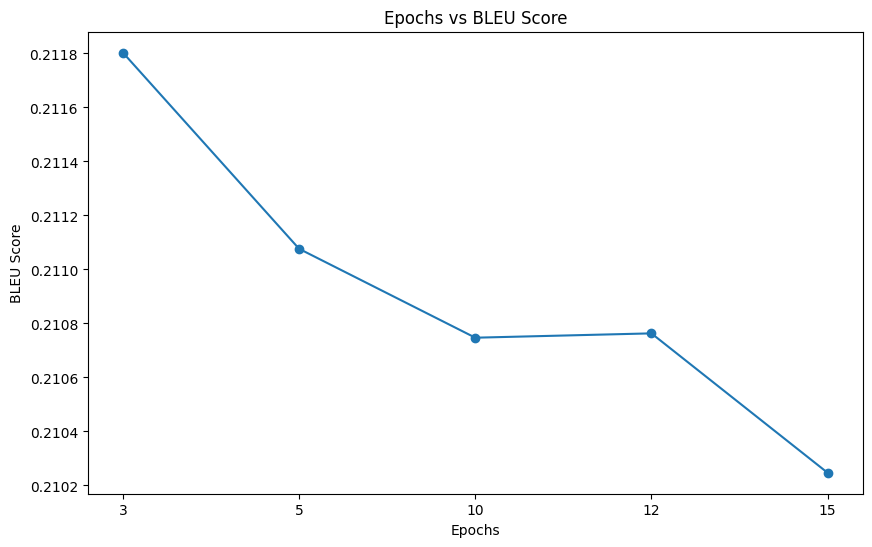

In [ ]:
# Plot epochs vs BLEU
plt.figure(figsize=(10, 6))
plt.plot(epochs[:len(BLEU_arr)], BLEU_arr, marker='o', label='BLEU Score')
plt.xlabel('Epochs')
plt.ylabel('BLEU Score')
plt.title('Epochs vs BLEU Score')
plt.savefig(os.path.join(plot_dir, 'epochs_vs_bleu.png'))
plt.xticks(epochs)
plt.show()

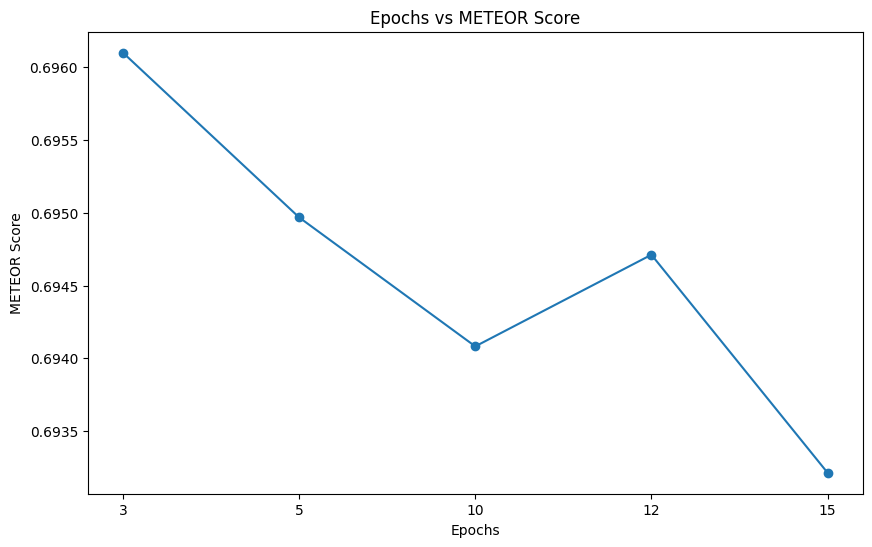

In [ ]:
# Plot epochs vs METEOR
plt.figure(figsize=(10, 6))
plt.plot(epochs[:len(METEOR_arr)], METEOR_arr, marker='o', label='METEOR Score')
plt.xlabel('Epochs')
plt.ylabel('METEOR Score')
plt.title('Epochs vs METEOR Score')
plt.savefig(os.path.join(plot_dir, 'epochs_vs_meteor.png'))
plt.xticks(epochs)
plt.show()

In [ ]:
# Plot epochs vs GLEU scores
plt.figure(figsize=(10, 6))
plt.plot(epochs[:len(GLEU_arr)], GLEU_arr, marker='o', label='GLEU Score')
plt.xlabel('Epochs')
plt.ylabel('GLEU Score')
plt.title('Epochs vs GLEU Score')
plt.savefig(os.path.join(plot_dir, 'epochs_vs_gleu.png'))
plt.xticks(epochs)
plt.show()

In [ ]:
# Plot epochs vs ROUGE scores
plt.figure(figsize=(10, 6))
plt.plot(epochs[:len(ROUGE1_arr)], ROUGE1_arr, marker='o', label='ROUGE-1')
plt.plot(epochs[:len(ROUGE2_arr)], ROUGE2_arr, marker='o', label='ROUGE-2')
plt.plot(epochs[:len(ROUGEL_arr)], ROUGEL_arr, marker='o', label='ROUGE-L')
plt.xlabel('Epochs')
plt.ylabel('ROUGE Score')
plt.title('Epochs vs ROUGE Scores')
plt.savefig(os.path.join(plot_dir, 'epochs_vs_rouge.png'))
plt.xticks(epochs)
plt.legend()
plt.show()

In [ ]:
# Plot epochs vs MoverScores
plt.figure(figsize=(10, 6))
plt.plot(epochs[:len(mover_arr)], mover_arr, marker='o', label='MoverScore')
plt.xlabel('Epochs')
plt.ylabel('MoverScore')
plt.title('Epochs vs MoverScore')
plt.savefig(os.path.join(plot_dir, 'epochs_vs_mover.png'))
plt.xticks(epochs)
plt.show()

In [ ]:
import os
from transformers import GPT2LMHeadModel

models = []
models_dir = 'drive/MyDrive/NAS/Israel/models/distilgpt2'

for fold_dir in os.listdir(models_dir):
  model = GPT2LMHeadModel.from_pretrained(os.path.join(models_dir, fold_dir), local_files_only=True)
  models.append(model)

models

[GPT2LMHeadModel(
   (transformer): GPT2Model(
     (wte): Embedding(50257, 768)
     (wpe): Embedding(1024, 768)
     (drop): Dropout(p=0.1, inplace=False)
     (h): ModuleList(
       (0-5): 6 x GPT2Block(
         (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
         (attn): GPT2SdpaAttention(
           (c_attn): Conv1D()
           (c_proj): Conv1D()
           (attn_dropout): Dropout(p=0.1, inplace=False)
           (resid_dropout): Dropout(p=0.1, inplace=False)
         )
         (ln_2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
         (mlp): GPT2MLP(
           (c_fc): Conv1D()
           (c_proj): Conv1D()
           (act): NewGELUActivation()
           (dropout): Dropout(p=0.1, inplace=False)
         )
       )
     )
     (ln_f): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
   )
   (lm_head): Linear(in_features=768, out_features=50257, bias=False)
 ),
 GPT2LMHeadModel(
   (transformer): GPT2Model(
     (wte): Embedding(50257, 768)
 

In [ ]:
!pip install onnx

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.9/15.9 MB 99.0 MB/s eta 0:00:00


In [ ]:
import torch
from transformers import GPT2Tokenizer
from datasets import load_dataset, concatenate_datasets

def tokenize_function(examples):
    # Tokenize the input text
    return tokenizer(examples['text'], truncation=True, padding='max_length', max_length=128)

model_names = ['distilgpt2_3epochs', 'distilgpt2_5epochs', 'distilgpt2_10epochs', 'distilgpt2_12epochs', 'distilgpt2_15epochs']
tokenizer = GPT2Tokenizer.from_pretrained('distilgpt2')

# Load the WikiText dataset
datasets = load_dataset('wikitext', 'wikitext-2-raw-v1')
dataset = concatenate_datasets([datasets['train'], datasets['validation']])

tokenizer.pad_token = tokenizer.eos_token
tokenized_dataset = dataset.map(tokenize_function, batched=True, remove_columns=["text"])

# Extract input_ids from tokenized dataset
input_ids = torch.tensor(tokenized_dataset['input_ids'])  # Convert to tensor

# Only take a small batch to avoid memory issues when exporting to ONNX
input_ids = input_ids[:1]  # Take a batch of size 1 for export

for index, model in enumerate(models):
    model_name = model_names[index]
    model.eval()

    # Export the model to ONNX using opset version 14
    torch.onnx.export(
        model,
        input_ids,
        f"drive/MyDrive/NAS/Israel/models/distilgpt2/onnx/{model_name}.onnx",
        input_names=["input_ids"],
        output_names=["output"],
        dynamic_axes={"input_ids": {0: "batch_size", 1: "sequence"}, "output": {0: "batch_size", 1: "sequence"}},
        opset_version=14  # Updated to opset version 14
    )
    print(f"Model {model_name} has been exported to ONNX with opset 14.")


Model distilgpt2_3epochs has been exported to ONNX with opset 14.
Model distilgpt2_5epochs has been exported to ONNX with opset 14.
Model distilgpt2_10epochs has been exported to ONNX with opset 14.
Model distilgpt2_12epochs has been exported to ONNX with opset 14.
Model distilgpt2_15epochs has been exported to ONNX with opset 14.
